In [209]:
import sklearn
from sklearn.datasets import make_circles

In [210]:
n_samples = 1000
x,y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [211]:
len(x),len(y)

(1000, 1000)

In [212]:
import pandas as pd
circles = pd.DataFrame({'x1':x[:,0],
                        'x2':x[:,1],
                        'label':y})
circles

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


In [213]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

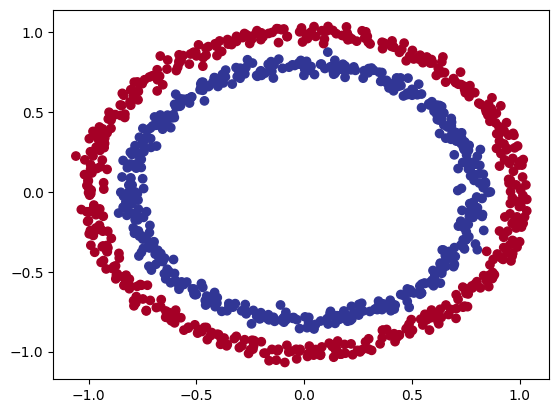

In [214]:
import matplotlib.pyplot as plt 
plt.scatter(x=x[:,0],y=x[:,1],c=y,cmap=plt.cm.RdYlBu)


In [215]:
x.shape,y.shape

((1000, 2), (1000,))

In [216]:
import torch 
x = torch.from_numpy(x).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [217]:
type(x)

torch.Tensor

In [218]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [219]:
len(x_train),len(x_test)

(800, 200)

## building the model

In [220]:
from torch import nn

device ="mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [221]:
x_train.shape

torch.Size([800, 2])

In [222]:
class circleModelv0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
        return self.layer_2(self.layer_1(x))

model_0 = circleModelv0().to(device)
model_0

circleModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

for smaller models we can also use sequential()

In [223]:
class circleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)


    def forward(self,x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = circleModelv1().to(device)
model_1

circleModelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [224]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='mps:0')),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='mps:0')),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='mps:0')),
             ('layer_2.bias', tensor([-0.2060], device='mps:0'))])

In [225]:
with torch.inference_mode(): 
    untrained_pred = model_0(x_test.to(device))
torch.round(untrained_pred)

tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-

which loss function to use ?

for regsression model we use MAE or MSE 

for classification model we use binary cross entropy or categorical cross entropy 

## BCELoss():
it requires the input to already have gone through a sigmoid dunction 

## BCEWithLogitsLoss():
has sigmoid built in hence more stable 

In [226]:
loss_fn = nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(params = model_0.parameters(),lr=0.1)

In [227]:
list(model_0.parameters())

[Parameter containing:
 tensor([[ 0.5406,  0.5869],
         [-0.1657,  0.6496],
         [-0.1549,  0.1427],
         [-0.3443,  0.4153],
         [ 0.6233, -0.5188]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='mps:0',
        requires_grad=True),
 Parameter containing:
 tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='mps:0',
        requires_grad=True),
 Parameter containing:
 tensor([-0.2060], device='mps:0', requires_grad=True)]

In [228]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc


In [229]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='mps:0')

In [230]:
y_pred_probs = torch.sigmoid(y_logits)
torch.round(y_pred_probs),y_test[:5]
torch.eq(y_pred_probs.squeeze(),y_test[:5].to(device))

tensor([False, False, False, False, False], device='mps:0')

In [231]:
torch.manual_seed(42)
epochs = 1000
x_test,y_test = x_test.to(device),y_test.to(device)
x_train,y_train = x_train.to(device),y_train.to(device)  
for epoch in range(epochs):
    model_1.train()
    y_logits = model_1(x_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(x_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch%10 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f}')

epoch: 0   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 10   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 20   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 30   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 40   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 50   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 60   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 70   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 80   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 90   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 100   | Loss: 0.70021.   | accuracy:  51.50   | test l

In [232]:
x_train,y_train


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]], device='mps:0'),
 tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
         0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1.,
         1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0.,
         0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 

In [233]:
import requests 
from pathlib import Path

if Path('helper_function.py').is_file():
    print("exist")

exist


In [234]:
from helper_function import plot_predictions,plot_decision_boundary

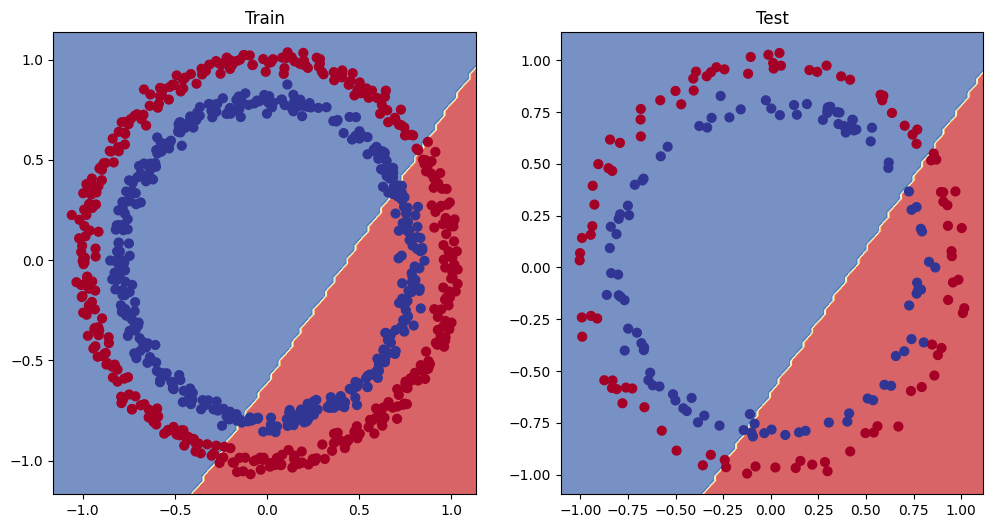

In [235]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, x_test, y_test)

## improving the model

* add more layers
* add more hidden units
* fit for longer -  add more epochs 
* changing the activation function 
* change the learning rate 
* change the loss function 

In [236]:
weight  = 0.7
bias = 0.3
start = 0
end =1
step = 0.01

x_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = weight*x_regression +bias
print(len(x_regression))

100


In [237]:
train_split = int(0.8*len(x_regression))
x_train_regression,y_train_regression = x_regression[:train_split],y_regression[:train_split]
x_test_regression, y_test_regression = x_regression[train_split:],y_regression[train_split:]
len(x_train_regression)

80

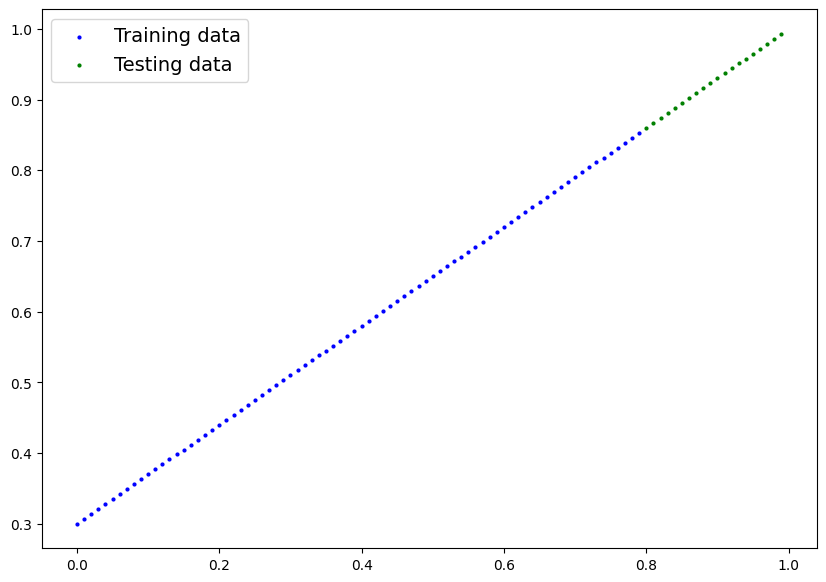

In [238]:
plot_predictions(train_data=x_train_regression,
                 train_labels=y_train_regression,
                 test_data=x_test_regression,
                 test_labels=y_test_regression)

In [239]:
class circleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=1,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)


    def forward(self,x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_2 = circleModelv1().to(device)
model_2

circleModelv1(
  (layer_1): Linear(in_features=1, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [240]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc


In [241]:
torch.manual_seed(42)
epochs = 1000
x_test1,y_test1 = x_test_regression.to(device),y_test_regression.to(device)
x_train1,y_train1 = x_train_regression.to(device),y_train_regression.to(device)  
loss_fn1 = nn.L1Loss()
optim1 = torch.optim.SGD(params = model_2.parameters(),lr=0.01)
for epoch in range(epochs):
    model_2.train()
    y_logits = model_2(x_train1)
    
    loss = loss_fn1(y_logits,y_train1)
    acc = 1 - (torch.abs(y_logits - y_train1)/y_train1).mean()
    optim1.zero_grad()
    loss.backward()
    optim1.step()
    
    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(x_test1)
        
        test_loss = loss_fn1(test_logits,y_test1)
        test_acc = 1 - (torch.abs(test_logits - y_test1)/y_test1).mean()
    if epoch%10 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f}')

epoch: 0   | Loss: 0.75986.   | accuracy: -0.39   | test loss:  0.91103   | test acc: 0.02
epoch: 10   | Loss: 0.40240.   | accuracy:  0.28   | test loss:  0.50474   | test acc: 0.45
epoch: 20   | Loss: 0.06007.   | accuracy:  0.91   | test loss:  0.10151   | test acc: 0.89
epoch: 30   | Loss: 0.01559.   | accuracy:  0.97   | test loss:  0.03231   | test acc: 0.97
epoch: 40   | Loss: 0.03092.   | accuracy:  0.94   | test loss:  0.00111   | test acc: 1.00
epoch: 50   | Loss: 0.03196.   | accuracy:  0.94   | test loss:  0.00108   | test acc: 1.00
epoch: 60   | Loss: 0.03192.   | accuracy:  0.94   | test loss:  0.00170   | test acc: 1.00
epoch: 70   | Loss: 0.03081.   | accuracy:  0.95   | test loss:  0.00097   | test acc: 1.00
epoch: 80   | Loss: 0.03077.   | accuracy:  0.95   | test loss:  0.00150   | test acc: 1.00
epoch: 90   | Loss: 0.02967.   | accuracy:  0.95   | test loss:  0.00092   | test acc: 1.00
epoch: 100   | Loss: 0.02858.   | accuracy:  0.95   | test loss:  0.00081   | tes

In [242]:
model_2.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.7474],
                      [ 0.8386],
                      [-0.2685],
                      [ 0.9277],
                      [-0.2253],
                      [ 0.2219],
                      [-0.5157],
                      [ 0.5984],
                      [ 0.8952],
                      [-0.7398]], device='mps:0')),
             ('layer_1.bias',
              tensor([ 0.8181,  0.1893,  0.6798,  0.1390,  0.4719, -0.1165,  0.7276,  0.1469,
                      -0.4521,  0.2444], device='mps:0')),
             ('layer_2.weight',
              tensor([[-6.8272e-02,  4.0207e-03, -9.4606e-02,  2.5110e-01, -2.2979e-01,
                       -1.4690e-01, -6.2611e-02, -1.6088e-01,  3.5127e-02, -3.2492e-01],
                      [ 3.0631e-01, -2.5446e-01,  2.4940e-01,  6.7609e-02, -1.0098e-01,
                        1.9585e-01,  5.0876e-02,  2.6490e-01,  4.2846e-02, -1.0855e-01],
                      [ 8.2267e-03, -1.2545e-01,  

In [243]:
list(model_2.parameters())

[Parameter containing:
 tensor([[ 0.7474],
         [ 0.8386],
         [-0.2685],
         [ 0.9277],
         [-0.2253],
         [ 0.2219],
         [-0.5157],
         [ 0.5984],
         [ 0.8952],
         [-0.7398]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([ 0.8181,  0.1893,  0.6798,  0.1390,  0.4719, -0.1165,  0.7276,  0.1469,
         -0.4521,  0.2444], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([[-6.8272e-02,  4.0207e-03, -9.4606e-02,  2.5110e-01, -2.2979e-01,
          -1.4690e-01, -6.2611e-02, -1.6088e-01,  3.5127e-02, -3.2492e-01],
         [ 3.0631e-01, -2.5446e-01,  2.4940e-01,  6.7609e-02, -1.0098e-01,
           1.9585e-01,  5.0876e-02,  2.6490e-01,  4.2846e-02, -1.0855e-01],
         [ 8.2267e-03, -1.2545e-01,  9.8334e-02,  2.4267e-01,  1.6198e-01,
          -1.3694e-01,  1.5432e-01,  2.8052e-02,  1.5759e-01, -1.8208e-01],
         [-2.4582e-01, -8.8447e-02, -2.1083e-01,  2.9292e-01,  1.1053e-01,
           1.2957e-

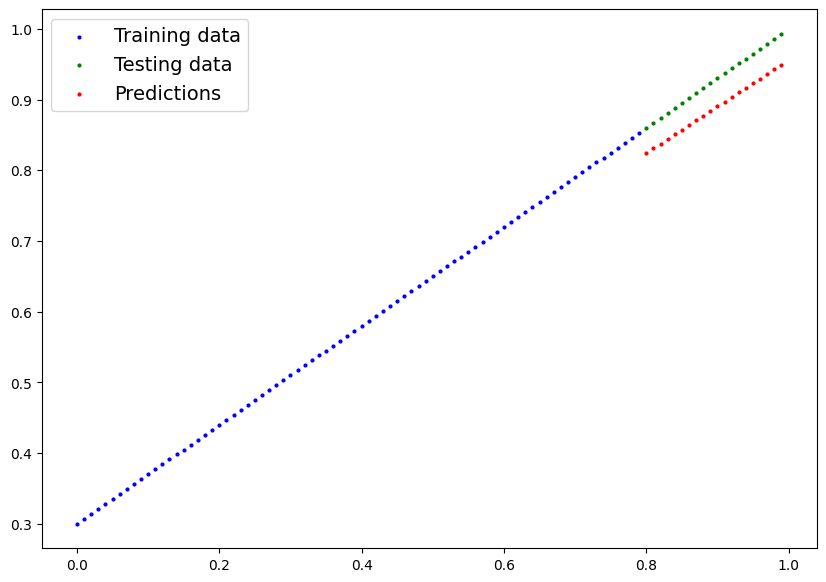

In [244]:
model_2.eval()
with torch.inference_mode():
    y_pred = model_2(x_test1)

plot_predictions(train_data=x_train1.cpu(),
                 train_labels=y_train1.cpu(),
                 test_data=x_test1.cpu(),
                 test_labels=y_test1.cpu(),
                 predictions=y_pred.cpu())

## how to see the number of parameter in model


In [245]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_2.parameters()).values())
unique_params

141

# making model for non linear data 

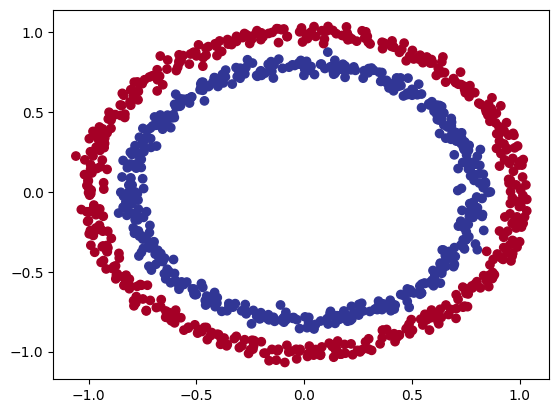

In [246]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
x,y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdYlBu)

In [247]:
import torch
from sklearn.model_selection import train_test_split

x = torch.from_numpy(x).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

x_train2,x_test2,y_train2,y_test2 = train_test_split(x,y,train_size=0.8,random_state=42)
x_train2[:5],y_train2[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [248]:
from torch import nn
class cricleModelv2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)
        self.relu = nn.ReLU()  #non linear activation function


    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_3 = cricleModelv2().to(device)
model_3

cricleModelv2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [249]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_3.parameters()).values())
unique_params

151

In [250]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='mps:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='mps:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222,

In [251]:
loss_fn = nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(params = model_3.parameters(),lr=0.1)

In [252]:
torch.manual_seed(42)
epochs = 1500
x_test,y_test = x_test2.to(device),y_test2.to(device)
x_train,y_train = x_train2.to(device),y_train2.to(device)  
for epoch in range(epochs):
    model_3.train()
    y_logits1 = model_3(x_train).squeeze()
    y_pred1 = torch.round(torch.sigmoid(y_logits1))
    loss = loss_fn(y_logits1,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred1)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    model_3.eval()
    with torch.inference_mode():
        test_logits1 = model_3(x_test).squeeze()
        test_pred1 = torch.round(torch.sigmoid(test_logits1))
        test_loss = loss_fn(test_logits1,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred1)
    if epoch%100 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f}')

epoch: 0   | Loss: 0.69295.   | accuracy:  50.00   | test loss:  0.69319   | test acc: 50.00
epoch: 100   | Loss: 0.69115.   | accuracy:  52.88   | test loss:  0.69102   | test acc: 52.50
epoch: 200   | Loss: 0.68977.   | accuracy:  53.37   | test loss:  0.68940   | test acc: 55.00
epoch: 300   | Loss: 0.68795.   | accuracy:  53.00   | test loss:  0.68723   | test acc: 56.00
epoch: 400   | Loss: 0.68517.   | accuracy:  52.75   | test loss:  0.68411   | test acc: 56.50
epoch: 500   | Loss: 0.68102.   | accuracy:  52.75   | test loss:  0.67941   | test acc: 56.50
epoch: 600   | Loss: 0.67515.   | accuracy:  54.50   | test loss:  0.67285   | test acc: 56.00
epoch: 700   | Loss: 0.66659.   | accuracy:  58.38   | test loss:  0.66322   | test acc: 59.00
epoch: 800   | Loss: 0.65160.   | accuracy:  64.00   | test loss:  0.64757   | test acc: 67.50
epoch: 900   | Loss: 0.62362.   | accuracy:  74.00   | test loss:  0.62145   | test acc: 79.00
epoch: 1000   | Loss: 0.56818.   | accuracy:  87.75 

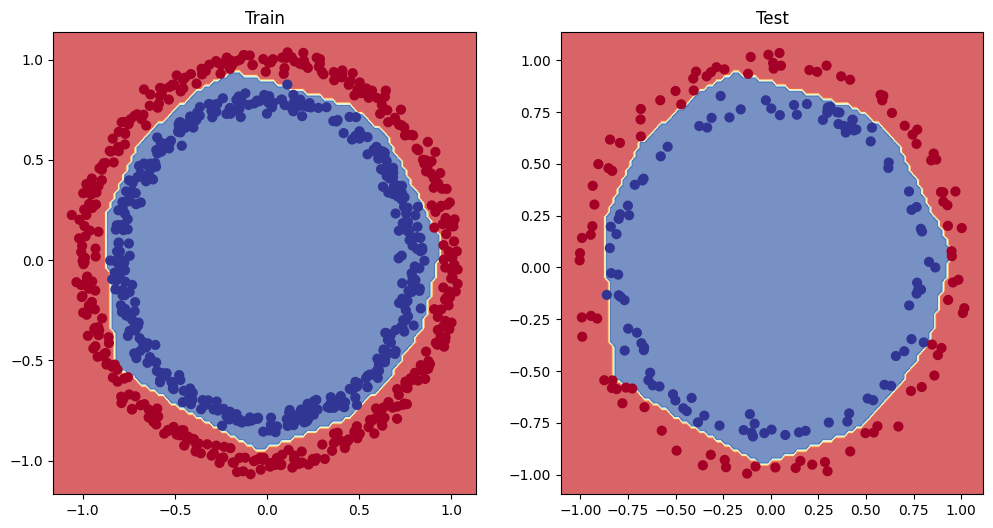

In [253]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, x_test, y_test)

In [254]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.8617,  1.4220],
                      [-0.4085,  1.5223],
                      [-0.1549,  0.1427],
                      [-1.9845, -0.1431],
                      [ 0.7161, -2.0640],
                      [ 1.0250, -0.0631],
                      [ 1.3191,  0.0347],
                      [ 0.3410, -0.0998],
                      [ 0.8574,  0.6342],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.2392, -0.6756, -0.2872, -0.2203, -0.5081, -0.4771, -0.6211, -0.4252,
                      -0.2083, -0.6984])),
             ('layer_2.weight',
              tensor([[-0.0100, -0.6111,  0.2441, -0.2669, -0.3924,  0.0047, -0.1580,  0.2555,
                       -0.1120, -0.0997],
                      [ 1.4653,  1.4202,  0.1331,  1.7681,  1.7783,  0.7737,  1.2075,  0.0566,
                        0.9194, -0.1927],
                      [-0.3130, -0.1243, -0.2426,  0.1835,  0.0911,  0.1

In [255]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME = "model_3.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model_3.state_dict(),
            f = MODEL_SAVE_PATH)



## multi class classification 

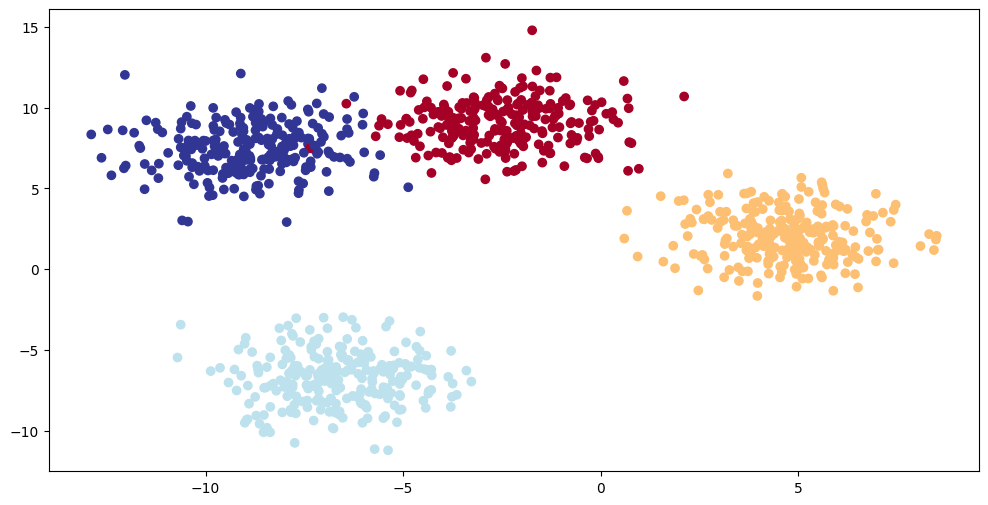

In [256]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from helper_function import plot_predictions,plot_decision_boundary
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42
device = "mps" if torch.mps.is_available() else "cpu"
x_blobs, y_blobs = make_blobs(n_samples=1000,
                              centers=NUM_CLASSES,
                              n_features=NUM_FEATURES,
                              cluster_std = 1.5,
                              random_state=RANDOM_SEED)
x_blobs = torch.from_numpy(x_blobs).type(torch.float32)
y_blobs = torch.from_numpy(y_blobs).type(torch.float32)

x_train_blobs, x_test_blobs, y_train_blobs, y_test_blobs = train_test_split(x_blobs,
                                                                          y_blobs,
                                                                          test_size=0.2,
                                                                          random_state=RANDOM_SEED)
plt.figure(figsize=(12,6))
plt.scatter(x_blobs[:,0],x_blobs[:,1],c=y_blobs,cmap=plt.cm.RdYlBu)



In [257]:
x_blobs.shape,y_blobs.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [258]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=10):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )

    def forward(self,x):
        return self.layer_stack(x)
    
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=10).to(device)
model_4.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='mps:0')),
             ('layer_stack.0.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='mps:0')),
             ('layer_stack.2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      

In [259]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_4.parameters()).values())
unique_params

184

in CrossEntropyLoss() has an attribute weights= which is used when the smaples are unbalanced 

In [260]:
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.SGD(params=model_4.parameters(),lr=0.1)

In [261]:
with torch.inference_mode():
    y =model_4(x_test_blobs.to(device))
y
y1 = torch.softmax(y,dim=1)
y1[:5],y_test_blobs[:5]

(tensor([[0.2180, 0.2516, 0.4114, 0.1190],
         [0.2064, 0.2873, 0.2985, 0.2078],
         [0.2553, 0.2744, 0.2633, 0.2069],
         [0.2225, 0.2492, 0.3765, 0.1518],
         [0.1875, 0.3432, 0.3440, 0.1254]], device='mps:0'),
 tensor([1., 3., 2., 1., 0.]))

In [262]:
y_test_blobs

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

In [263]:
y_preds = torch.argmax(y1,dim=1)
y_preds.type(torch.float32),y_test_blobs

(tensor([2., 2., 1., 2., 2., 2., 1., 1., 1., 1., 1., 2., 1., 1., 1., 2., 2., 2.,
         2., 2., 2., 1., 2., 1., 1., 2., 2., 1., 2., 1., 2., 2., 2., 2., 2., 1.,
         2., 2., 1., 1., 1., 2., 2., 1., 1., 1., 2., 2., 1., 2., 2., 1., 2., 2.,
         2., 1., 2., 2., 2., 1., 1., 1., 2., 1., 1., 1., 1., 2., 2., 1., 1., 2.,
         2., 2., 1., 2., 2., 2., 2., 2., 1., 1., 2., 2., 2., 2., 1., 2., 2., 1.,
         2., 2., 2., 2., 2., 2., 2., 1., 2., 1., 1., 1., 1., 1., 1., 2., 2., 1.,
         2., 1., 2., 2., 1., 1., 1., 2., 1., 1., 2., 2., 1., 2., 1., 2., 1., 1.,
         1., 1., 1., 2., 2., 1., 1., 1., 1., 2., 1., 1., 2., 2., 2., 1., 1., 1.,
         1., 2., 1., 2., 1., 2., 1., 2., 2., 2., 1., 2., 2., 2., 1., 2., 1., 1.,
         2., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2.,
         1., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1., 1., 2., 2., 1., 1., 2., 2.,
         1., 2.], device='mps:0'),
 tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3

In [264]:
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.SGD(params=model_4.parameters(),lr=0.1)

In [266]:
from torchmetrics.classification import MulticlassF1Score
torch.manual_seed(42)
epochs = 1000
x_test,y_test = x_test_blobs.to(device),y_test_blobs.to(device)
x_train,y_train = x_train_blobs.to(device),y_train_blobs.to(device)
for epoch in range(epochs):
    model_4.train()
    y_logits = model_4(x_train)
    y_pred= torch.softmax(y_logits,dim=1).argmax(dim=1)
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)
    optim.zero_grad()
    loss.backward()
    optim.step()

    model_4.eval()
    with torch.inference_mode():
        metric = MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(device)
        test_logits = model_4(x_test)
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=torch.softmax(test_logits,dim=1).argmax(dim=1))
        f1_score = metric(torch.softmax(test_logits,dim=1).argmax(dim=1),y_test)
    if epoch%100 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f} | F1 Score: {f1_score:.2f}')

epoch: 0   | Loss: 1.40627.   | accuracy:  1.62   | test loss:  1.37291   | test acc: 1.00 | F1 Score: 0.01
epoch: 100   | Loss: 0.03781.   | accuracy:  99.00   | test loss:  0.02900   | test acc: 99.50 | F1 Score: 1.00
epoch: 200   | Loss: 0.02931.   | accuracy:  99.00   | test loss:  0.01922   | test acc: 99.50 | F1 Score: 1.00
epoch: 300   | Loss: 0.02741.   | accuracy:  99.12   | test loss:  0.01679   | test acc: 99.50 | F1 Score: 1.00
epoch: 400   | Loss: 0.02649.   | accuracy:  99.12   | test loss:  0.01559   | test acc: 99.50 | F1 Score: 1.00
epoch: 500   | Loss: 0.02588.   | accuracy:  99.12   | test loss:  0.01482   | test acc: 99.50 | F1 Score: 1.00
epoch: 600   | Loss: 0.02539.   | accuracy:  99.25   | test loss:  0.01426   | test acc: 99.50 | F1 Score: 1.00
epoch: 700   | Loss: 0.02498.   | accuracy:  99.25   | test loss:  0.01381   | test acc: 99.50 | F1 Score: 1.00
epoch: 800   | Loss: 0.02460.   | accuracy:  99.25   | test loss:  0.01342   | test acc: 99.50 | F1 Score: 1

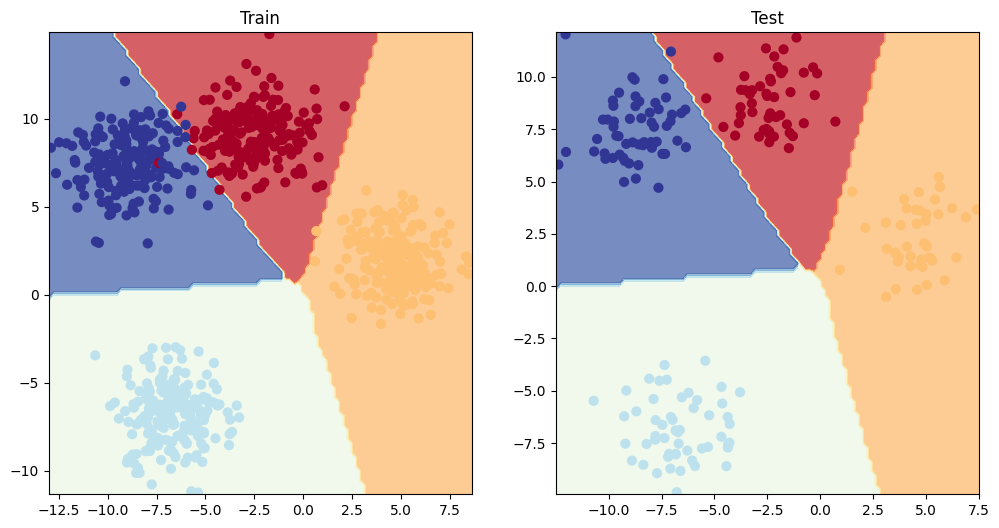

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, x_test, y_test)

## other classification matrics
* accuracy
* precision 
* recall
* f1 score
* confusion matrix 
* classification report 
